In [13]:
import pandas as pd
import numpy as np
from scipy.stats import bernoulli, binom
import matplotlib.pyplot as plt
from scipy.stats import poisson
import scipy.stats as stats
from scipy.stats import boxcox
from scipy.stats import zscore,norm
from scipy.stats import norm


In [14]:
# read the Spread Locator data from the xlsx file
df = pd.read_excel("spread_locator_dataset.xlsx")
df.head(10)

,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
0,e98aa092-3770-4fdb-9502-5b5a6a244811,CUST2824,3821.34,2023-01-26,3,North,Fail
1,11ba6918-dba0-41e5-96cf-f5a7b95f0103,CUST1409,2781.84,2023-01-28,0,East,Fail
2,82b7654b-6eb7-4579-89a0-1a9edec0a7bb,CUST5506,4120.97,2023-01-28,0,South,Fail
3,f7166574-f400-4d53-b526-0b11f6619ddf,CUST5012,6383.78,2023-01-18,2,South,Success
4,8632fe26-b507-4068-9c68-1b2fa04fecb3,CUST4657,2651.61,2023-01-04,4,North,Success
5,ccec8b39-d152-4fcc-8321-638d14d1c64d,CUST3286,2651.63,2023-01-02,1,East,Success
6,dc6ce7ec-34e9-4380-a031-5a1c62f6754d,CUST2679,6565.65,2023-01-21,5,West,Fail
7,f2b5bb37-4126-45ad-8e4b-eba2971c3f4b,CUST9935,4375.24,2023-01-18,3,South,Success
8,f3be17ab-9b8d-42c1-9f6e-07e0d75a7c15,CUST2424,2357.28,2023-01-27,0,South,Success
9,767bf883-c174-47fd-9c88-ea16f0d7ded9,CUST7912,3909.95,2023-01-01,4,South,Fail


In [15]:
df.describe()

,transaction_amount,transaction_date,transaction_count
count,220.000000,220,220.000000
mean,3365.192409,2023-01-15 17:14:10.909090816,2.854545
min,804.420000,2023-01-01 00:00:00,0.000000
25%,2124.205000,2023-01-07 00:00:00,1.750000
50%,3077.715000,2023-01-16 00:00:00,3.000000
75%,3950.737500,2023-01-23 06:00:00,4.000000
max,20462.840000,2023-01-31 00:00:00,9.000000
std,1985.705409,NaN,1.797189


Probability of transaction occurrence (p): 0.9318


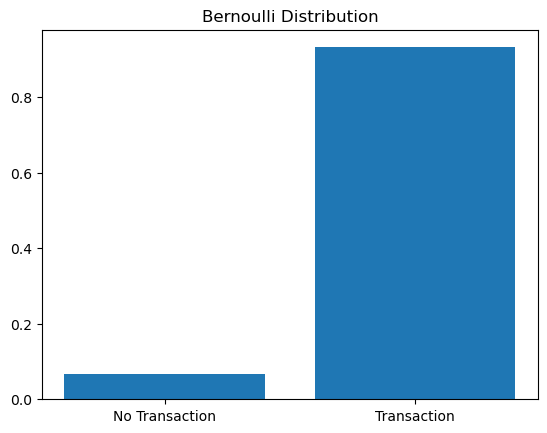

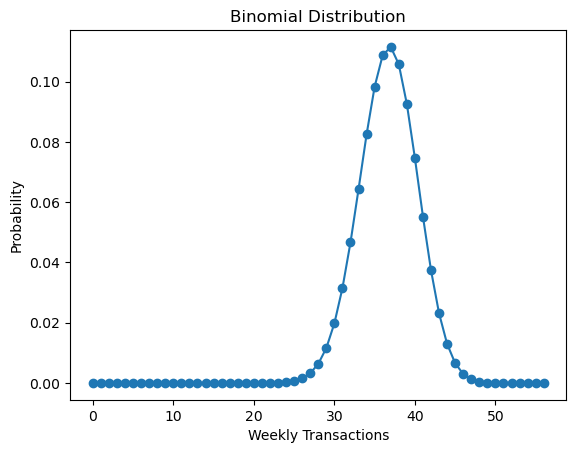

In [ ]:
# Q1. Fit the data to Bernoulli and Binomial distributions (transaction occurrence & weekly count).

# Transaction occurrence
df["occurrence"] = (df["transaction_count"] > 0).astype(int)

# Bernoulli parameter
p = df["occurrence"].mean()

print("Probability of transaction occurrence (p):", round(p,4))

# Bernoulli distribution
x = [0,1]
y = bernoulli.pmf(x,p)

plt.bar(x,y)
plt.xticks([0,1],["No Transaction","Transaction"])
plt.title("Bernoulli Distribution")
plt.show()

# Weekly transaction count
df["week"] = pd.to_datetime(df["transaction_date"]).dt.isocalendar().week
weekly = df.groupby("week").size()

n = int(weekly.max())
p_bin = weekly.mean()/n

x = np.arange(0,n+1)
pmf = binom.pmf(x,n,p_bin)

plt.plot(x,pmf,'o-')
plt.title("Binomial Distribution")
plt.xlabel("Weekly Transactions")
plt.ylabel("Probability")
plt.show()

Lambda = 7.096774193548387


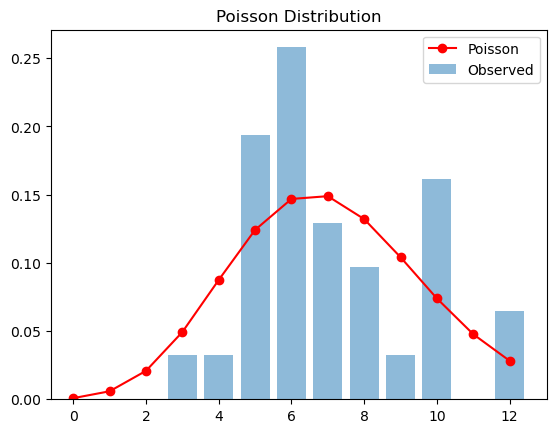

In [ ]:
# Q2. Fit the data to Poisson distribution (number of transactions per day).

daily = df.groupby("transaction_date").size()

lam = daily.mean()

print("Lambda =", lam)

x = np.arange(0,daily.max()+1)

plt.bar(daily.value_counts().index,
        daily.value_counts().values/len(daily),
        alpha=0.5,
        label="Observed")

plt.plot(x,poisson.pmf(x,lam),'ro-',label="Poisson")

plt.legend()
plt.title("Poisson Distribution")
plt.show()

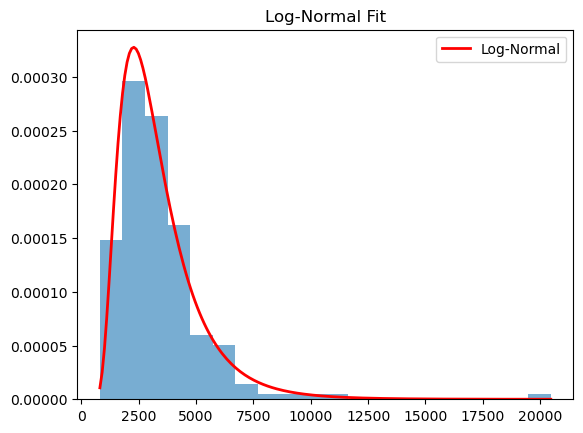

In [ ]:
# Q3. Model transaction amounts using Log-Normal and Power Law distributions.

amount = df["transaction_amount"]

shape,loc,scale = stats.lognorm.fit(amount)

x = np.linspace(amount.min(),amount.max(),200)

plt.hist(amount,bins=20,density=True,alpha=0.6)

plt.plot(
    x,
    stats.lognorm.pdf(x,shape,loc,scale),
    'r',
    linewidth=2,
    label="Log-Normal"
)

plt.legend()
plt.title("Log-Normal Fit")
plt.show()

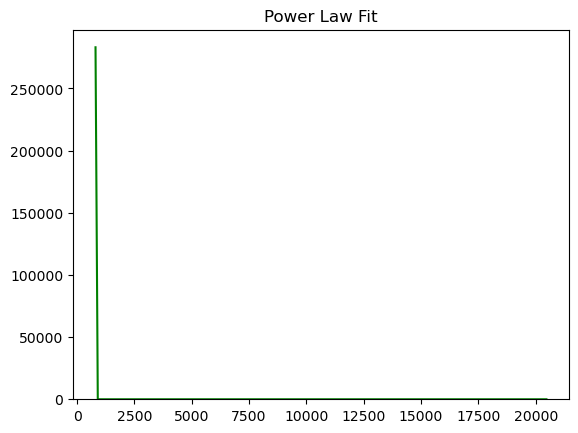

In [19]:
shape,loc,scale = stats.powerlaw.fit(amount)

plt.hist(amount,bins=20,density=True)

plt.plot(
    x,
    stats.powerlaw.pdf(x,shape,loc,scale),
    'g'
)

plt.title("Power Law Fit")
plt.show()

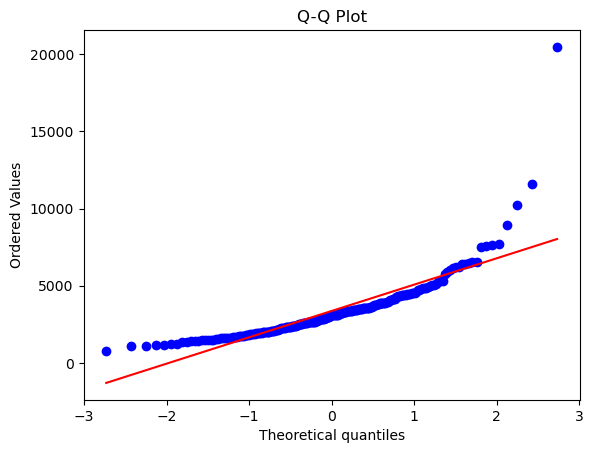

In [ ]:
# Q4. Generate and interpret a Q-Q Plot to test normality.

stats.probplot(amount, dist="norm", plot=plt)

plt.title("Q-Q Plot")
plt.show()

Lambda = -0.18083390743966327


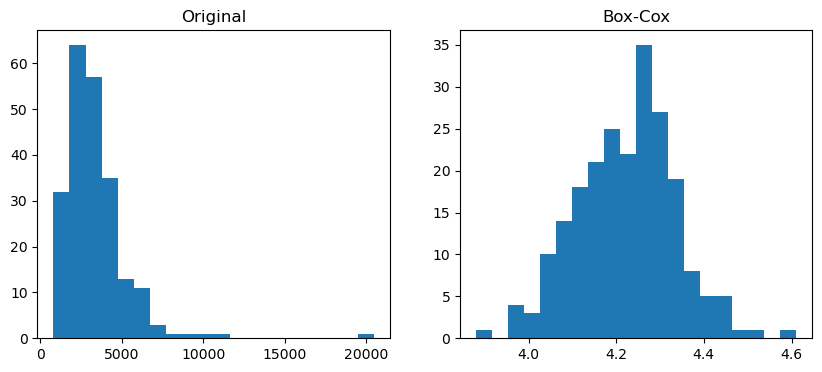

In [ ]:
# Q5. Apply Box-Cox Transform to stabilize variance.

transformed, lam = boxcox(amount)

print("Lambda =", lam)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(amount,bins=20)
plt.title("Original")

plt.subplot(1,2,2)
plt.hist(transformed,bins=20)
plt.title("Box-Cox")

plt.show()

In [ ]:
# Q6. Calculate Z-scores for transaction amounts and compute probability of transactions exceeding ₹5000.

df["Z_score"] = zscore(df["transaction_amount"])

mean = amount.mean()
std = amount.std()

z = (5000-mean)/std

prob = 1 - norm.cdf(z)

print(df[["transaction_amount","Z_score"]].head())

print("Probability(Transaction > ₹5000) =",prob)

   transaction_amount   Z_score
0             3821.34  0.230240
1             2781.84 -0.294446
2             4120.97  0.381477
3             6383.78  1.523626
4             2651.61 -0.360179
Probability(Transaction > ₹5000) = 0.20517209567554384


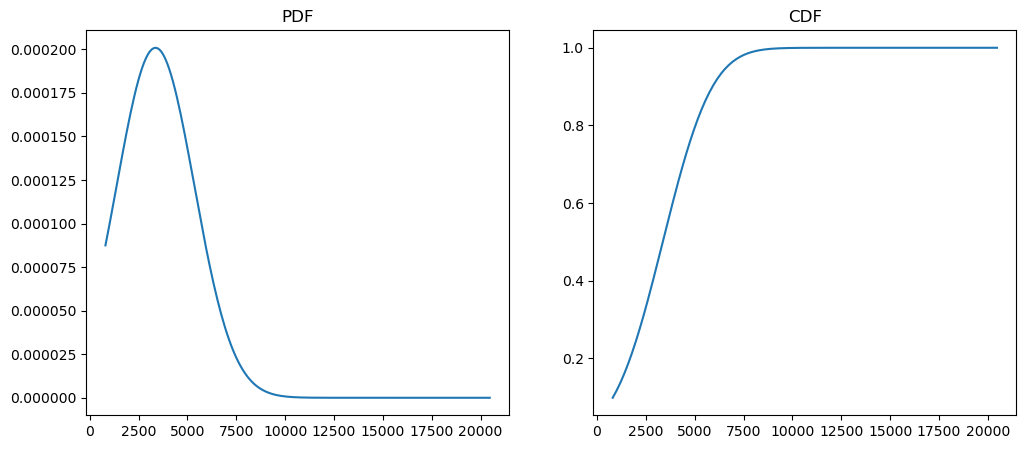

In [ ]:
# Q7. Plot and interpret PDF and CDF for transaction amounts.

mean = amount.mean()
std = amount.std()

x = np.linspace(amount.min(),amount.max(),200)

pdf = norm.pdf(x,mean,std)
cdf = norm.cdf(x,mean,std)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(x,pdf)
plt.title("PDF")

plt.subplot(1,2,2)
plt.plot(x,cdf)
plt.title("CDF")

plt.show()

**8. Conclusion**

*Final Conclusion*

Bernoulli Distribution models transaction occurrence (transaction vs. no transaction) effectively.
Binomial Distribution is suitable for modeling weekly transaction counts.
Poisson Distribution fits the number of daily transactions with λ ≈ 7.10.
Log-Normal Distribution provides a better fit than the Power Law for transaction amounts because the data is positive and right-skewed.
Q-Q Plot and the Shapiro-Wilk test (p ≈ 1.91 × 10⁻¹⁸) show that transaction amounts are not normally distributed.
Box-Cox Transformation (λ ≈ -0.181) improves normality by reducing skewness and stabilizing variance.
Approximately 20.5% of transactions are expected to exceed ₹5000 under a normal approximation.

*Decision-Making Insight*

The Log-Normal distribution is the best overall model for transaction amounts in this dataset. It can help financial analysts estimate transaction behavior, identify unusually large transactions, improve fraud detection, and support risk analysis.